# EDA

## Обзор данных (data overview)

Импорт библиотек

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка данных

In [3]:
train = pd.read_csv("../data/raw/train.csv")

Количество объектов

In [4]:
train.shape

(891, 12)

Количество признаков

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Типы признаков


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Статистика для числовых признаков

In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Статистика для категориальных признаков

In [8]:
train.describe(include='object')

C:\Users\Владимир\AppData\Local\Temp\ipykernel_5220\1464152888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Наличие признаков

In [9]:
train.isna().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Количество уникальных значений

In [10]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Разделим на числовые и категориальные признаки

In [162]:
num_features = ['Age', 'Fare', 'SibSp', 'Parch']
cat_features = ['Sex', 'Embarked', 'Pclass']

drop_features = ['PassengerId']

# Признаки, возможно содержащие полезную ифнмоцию, но требующие специальной обработки
special_features = ['Name', 'Ticket', 'Cabin']

## Анализ качества данных

### Пропуски

In [12]:
train.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

### Дубликаты

In [13]:
train.duplicated().sum()

np.int64(0)

### Некорректные значения

In [14]:
train.max()

PassengerId                            891
Survived                                 1
Pclass                                   3
Name           van Melkebeke, Mr. Philemon
Sex                                   male
Age                                   80.0
SibSp                                    8
Parch                                    6
Ticket                           WE/P 5735
Fare                              512.3292
Cabin                                    T
Embarked                                 S
dtype: object

In [15]:
train.min()

PassengerId                      1
Survived                         0
Pclass                           1
Name           Abbing, Mr. Anthony
Sex                         female
Age                           0.42
SibSp                            0
Parch                            0
Ticket                      110152
Fare                           0.0
Cabin                          A10
Embarked                         C
dtype: object

In [16]:
for col in cat_features + ordinal_features:
    print(train[col].value_counts())
    print()

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64



## Анализ целевой переменной

In [17]:
target = 'Survived'

### Распределение классов

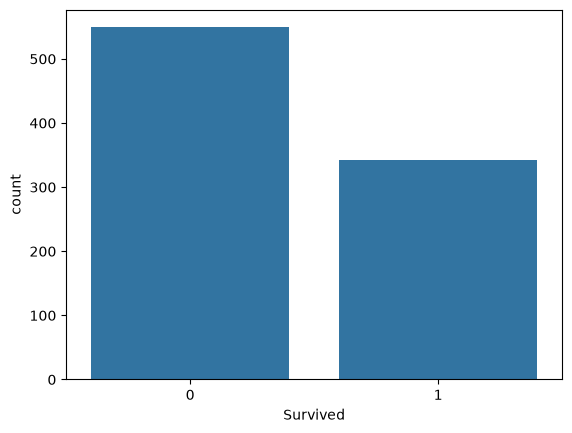

Survived
0    549
1    342
Name: count, dtype: int64

In [42]:
sns.countplot(data=train, x=target)
plt.show()
train[target].value_counts()

In [19]:
train[target].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Target имеет умеренный дисбаланс классов: 61.6% объектов относятся к классу 0 и 38.4% — к классу 1.  
Выраженного дисбаланса, требующего обязательного применения методов балансировки, не наблюдается.

### Анализ числовых признаков

In [37]:
num_features

['Age', 'Fare', 'SibSp', 'Parch']

In [139]:
def analysis_of_numerical_features(col):
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 3, 1)
    sns.histplot(data=train, x=col, kde=True)
    plt.subplot(1, 3, 2)
    sns.boxplot(data=train, x=col);
    

    

    # Связь числовых признаков с целевой переменной 
    plt.subplot(1, 3, 3)
    sns.boxplot(data=train, x=target, y=col)
    plt.show()
    print(train[col].describe())
    print()
    print(train.groupby(target)[col].describe())

**Age**  
Тип: непрерывный числовой   
Нормальность: распредление близко к нормальному, однако правый хвост более вытянут  
Асимметрия: умеренная правосторонняя асимметрия  
Моды: выделяется околонулевая вторая мода  
Наблюдаются небольшое количество редких значений, не похоже на выбросы

Связь с целевой пременной:  

Среднее значение признака Age для обоих групп примерно равны, для target = 1 среднее немного ниже  
Медианы совпадают  
Распределения схожи, значимых различий не наблюдается 


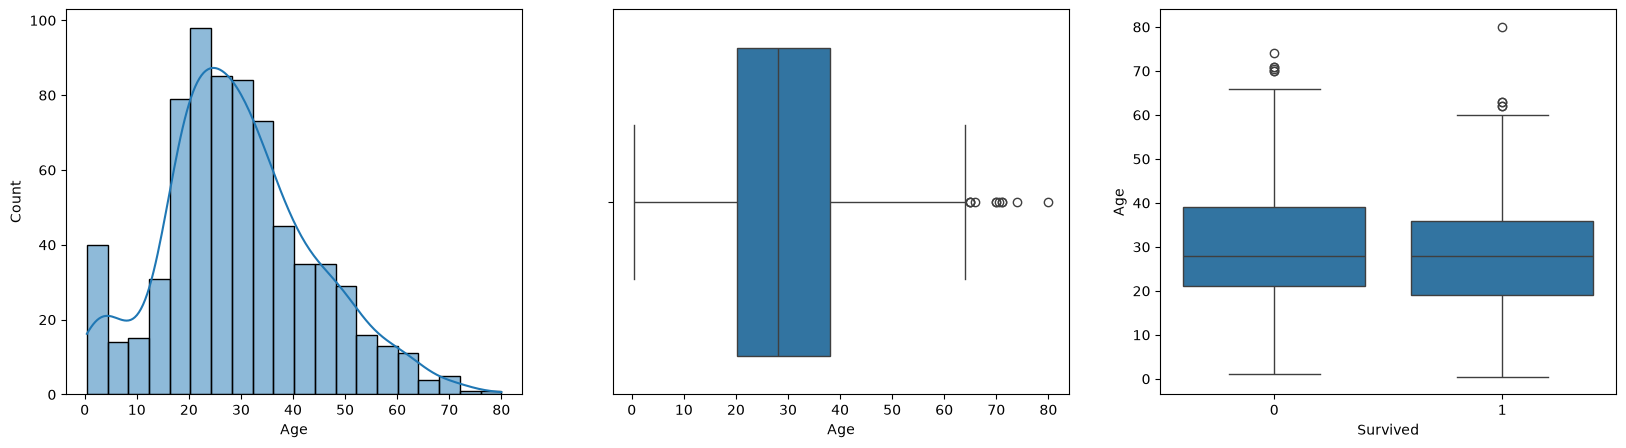

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


In [140]:
analysis_of_numerical_features('Age')

**Fare**  
Тип: непрерывный числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  
Наблюдаются множество редких значений, не похоже на выбросы

Среднее признака Fare выше для 1 категории таргет  
Медианы также сильно отличаются  
Распределения признака Fare для групп таргета различны

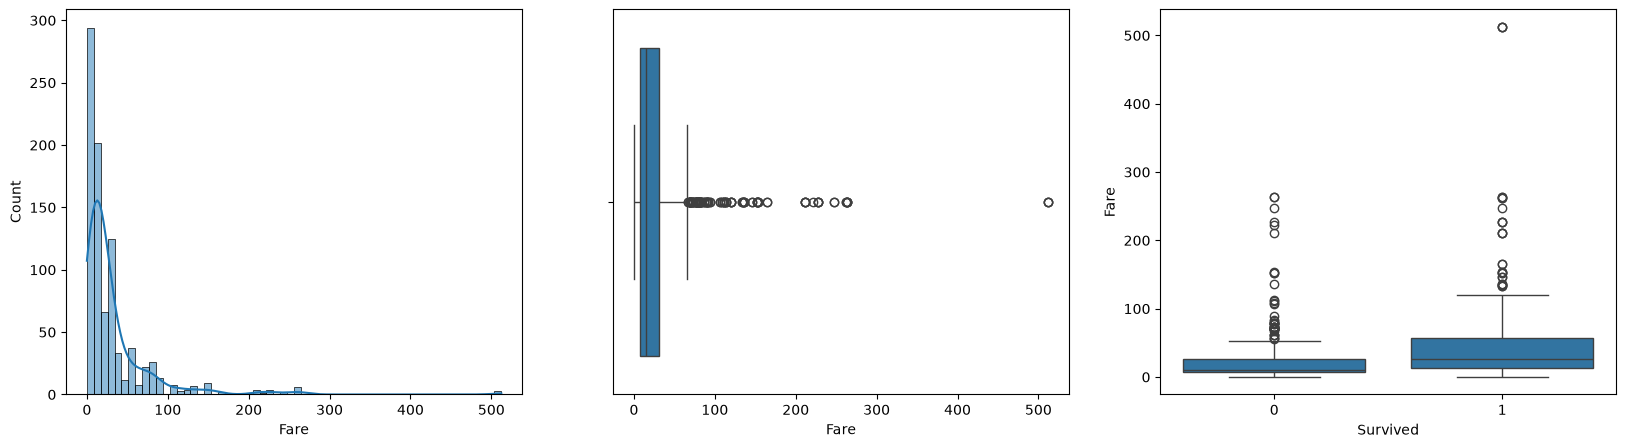

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [141]:
analysis_of_numerical_features('Fare')

**SibSp**  
Тип: дискретны числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  
Наблюдаются небольшое количество редких значений, не похоже на выбросы

Среднее признака SibSp между категориями не значительно выше для 0 категории таргета  
Медианы равны  
Распределения признака SibSp для групп таргета похожи

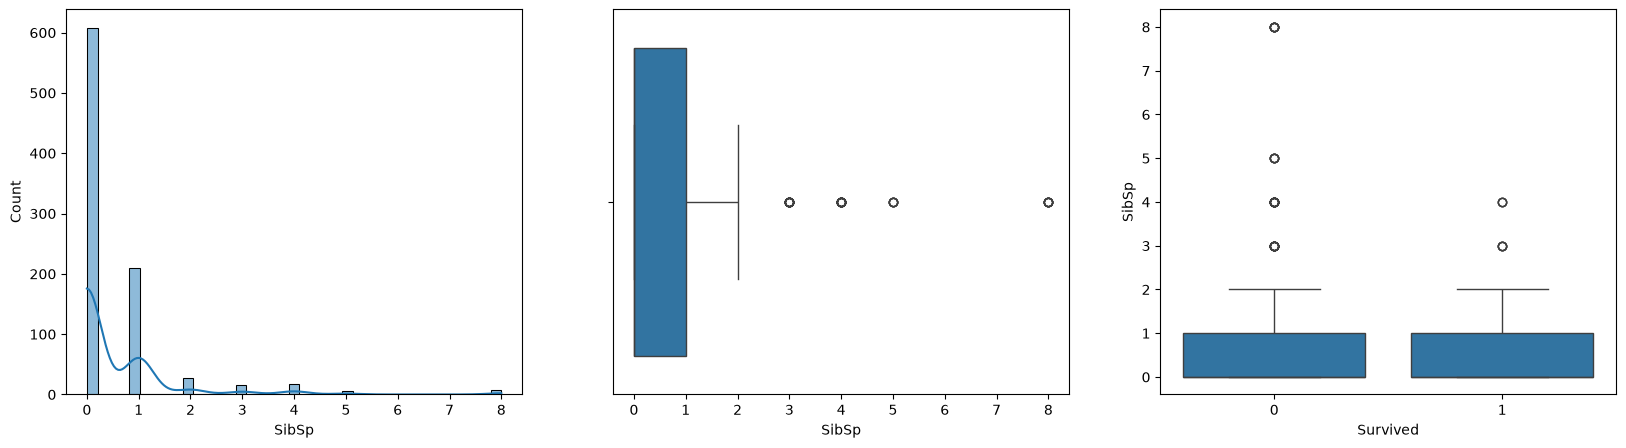

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

          count      mean       std  min  25%  50%  75%  max
Survived                                                    
0         549.0  0.553734  1.288399  0.0  0.0  0.0  1.0  8.0
1         342.0  0.473684  0.708688  0.0  0.0  0.0  1.0  4.0


In [142]:
analysis_of_numerical_features('SibSp')

**Parch**  
Тип: дискретны числовой   
Нормальность: нормальность распределения отсутствует  
Асимметрия: сильная правосторонняя асимметрия   
Моды: мода одна - околонулевая  
Наблюдаются небольшое количество редких значений, не похоже на выбросы

Среднее признака Parch между категориями выше для 1 категории таргета  
Медианы равны  
Распределения признака Parch для групп различны

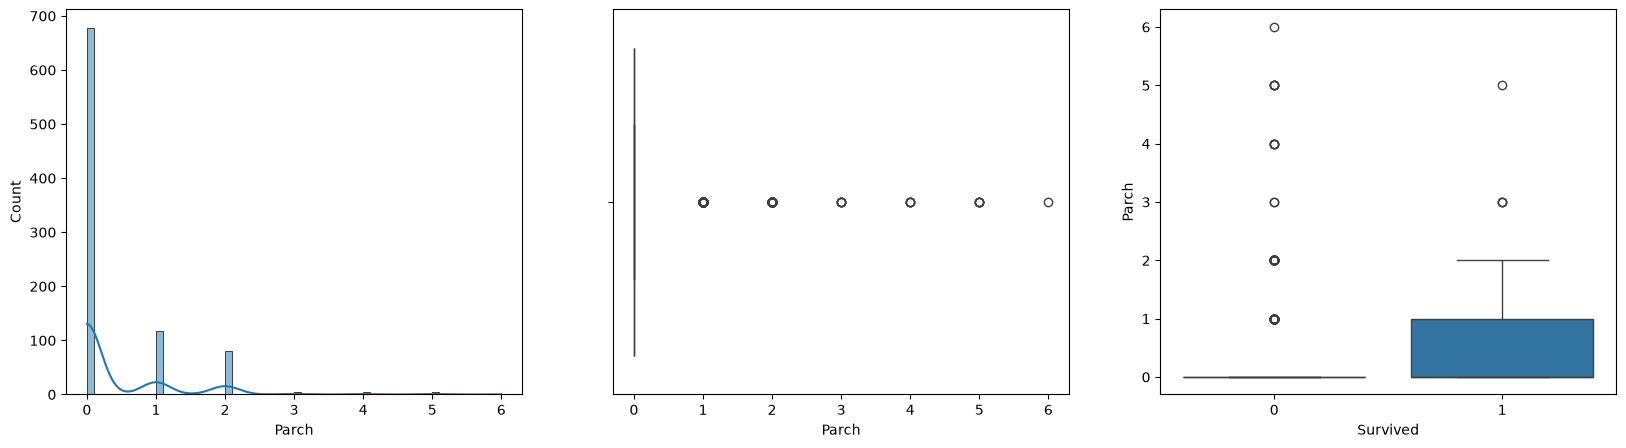

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

          count      mean       std  min  25%  50%  75%  max
Survived                                                    
0         549.0  0.329690  0.823166  0.0  0.0  0.0  0.0  6.0
1         342.0  0.464912  0.771712  0.0  0.0  0.0  1.0  5.0


In [143]:
analysis_of_numerical_features('Parch')

### Анализ категориальных признаков

In [36]:
cat_features + ordinal_features

['Sex', 'Embarked', 'Pclass']

In [146]:
def analysis_of_categorical_features(col):
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    sns.countplot(data=train, x=col)

    plt.subplot(1, 2, 2)
    sns.barplot(
        data=train,
        x=col,
        y=target
    )
    plt.show()

    print(train[col].value_counts(normalize=True))
    print()
    print(pd.crosstab(
        train[col],
        train[target],
        normalize='index'
    ))

**Sex**  
Переменная имеет 2 категории  
Наблюдается умеренный дисбаланс: male(64.7%)  
Доля объектов с target = 1 в категории female гораздо выше, чем у male.  
Это указывает на сильную связь Sex и Target  

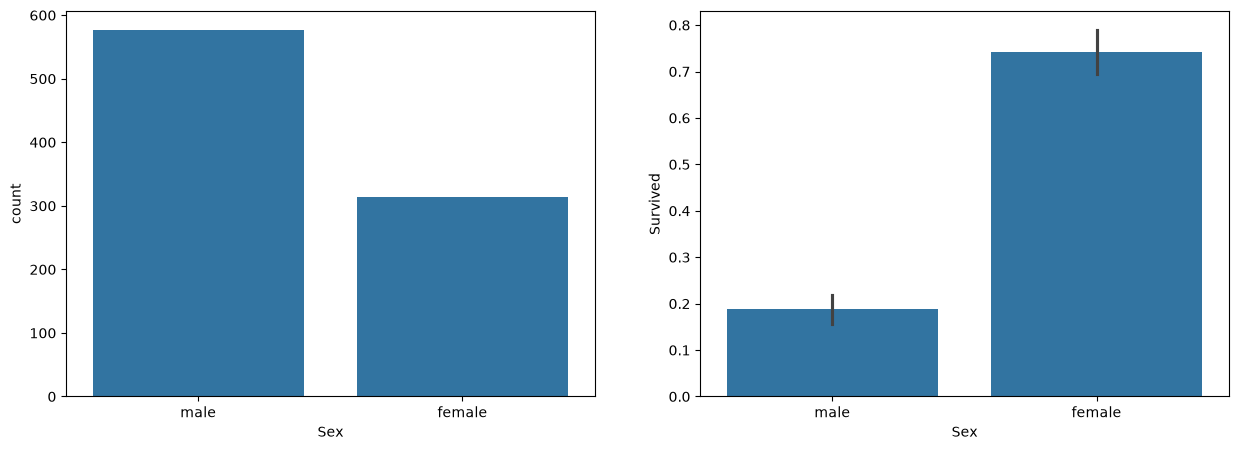

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


In [147]:
analysis_of_categorical_features('Sex')

**Embarked**  
Переменная имеет 3 категории  
Категория S встречается чаще всего (72,2 %)
Категория Q встречается реже всего (8,6 %)  

Доля объектов с target = 1 в категории С выше, чем у male.   
Это указывает на наличие связи между признаком Embarked и таргетом 

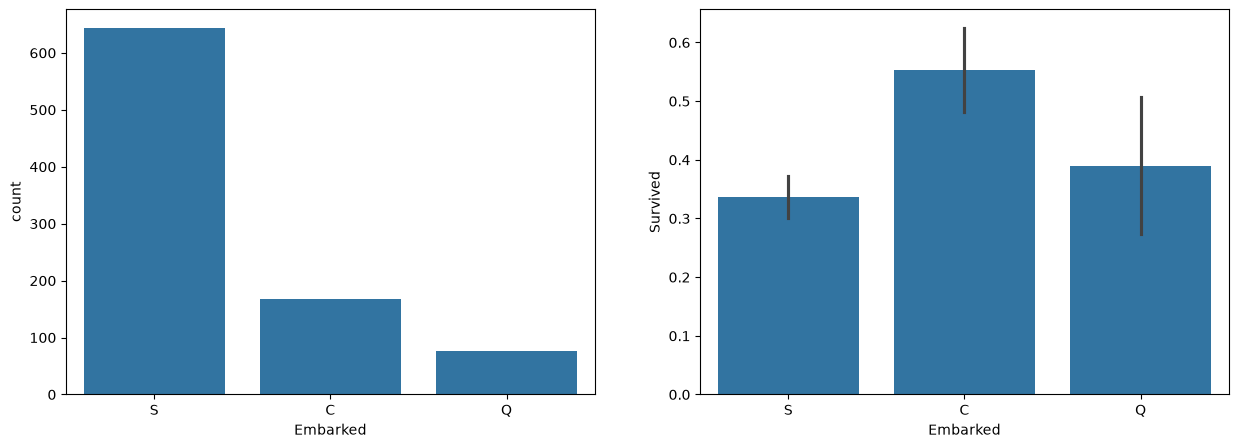

Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

Survived         0         1
Embarked                    
C         0.446429  0.553571
Q         0.610390  0.389610
S         0.663043  0.336957


In [148]:
analysis_of_categorical_features('Embarked')

**Pclass**  
Переменная имеет 3 категории  
Категория 3 встречается чаще всего (55,1 %)  
Наблюдается прямая связь меджу категориями призака Pclass и таргетом  
Видна иерархия между категориями

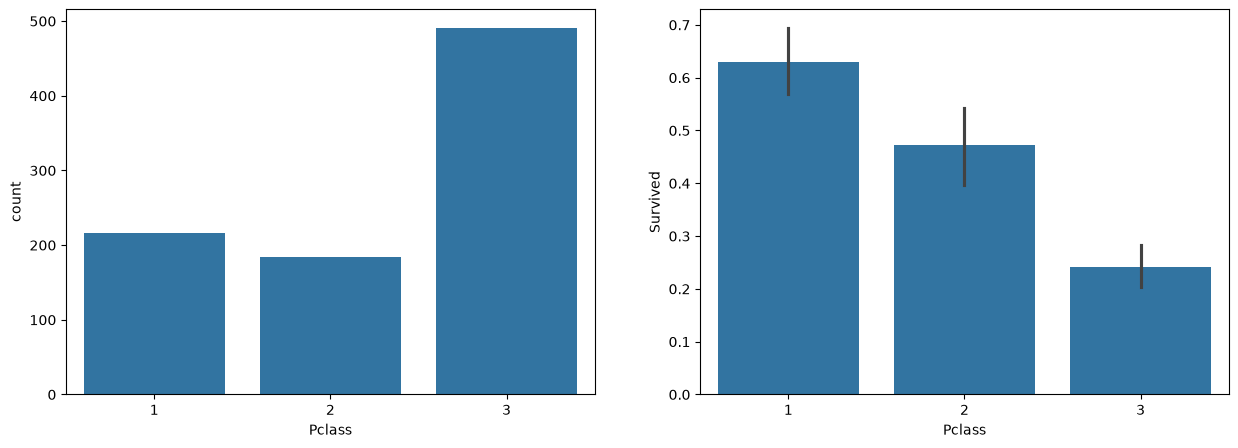

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


In [149]:
analysis_of_categorical_features('Pclass')

### Анализ специальных признаков

In [45]:
special_features

['Name', 'Ticket', 'Cabin']

На текущем этапе работы анализ специальных признаков, потенциально несущих полезную информацию, опускается

### Связь между числовыми признаками

Корреляционная матрица показывает, что между прищнаками отсутствует сильная линейная зависисомсть  
Наибольшая корреляция наблюдается между признаками **SibSp** и **Parch** - **0.41**  
Наибольшая линейная зависимость между числовыми признаками и таргетом проявляется у признака **Fare** - **0.26**  
Это модет говорить об отсутствии утечки данных

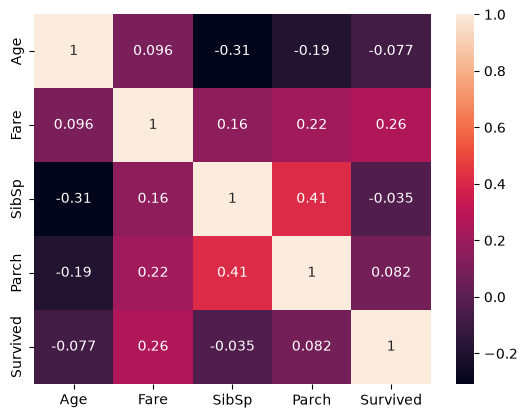

In [158]:
plt.figure()
sns.heatmap(train[num_features + [target]].corr(),
            annot=True
)
plt.show()

### Связь между категориальными признаками

Анализ связи между **Sex** и **Pclass** показывает, что и мужчин и женщин больше всего в третьем классе. При этом в 3ем классе мужчин больше более чем в 2 раза

In [159]:
pd.crosstab(train['Sex'], train['Pclass'])

Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347


Анализ связи между **Sex** и **Embarked** показывает, что больше всего пассажиров обоих полов сели в порту S, при этом, если в портах C и Q количество мужчин и женщин примерно рабвно, то в порту S мужчин в 2 раза больше 

In [160]:
pd.crosstab(train['Sex'], train['Embarked'])

Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441


Анализ связи между **Pclass** и **Embarked** показывает, что в порту Q подавляющее большенство пассажиров были из 3 класса, похожая ситуавця в порту S, наибольшая доля пассажиров первого класса наблюдается в порту C (около 50 %)

In [161]:
pd.crosstab(train['Pclass'], train['Embarked'])

Embarked,C,Q,S
Pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353
